In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ["OMP_NUM_THREADS"] = '1'
from mpi4py import MPI
import numpy as np
import quimb.tensor as qtn
import pickle
from functools import partial
import torch
import json
import autoray as ar
# ==============================================================================
from vmc_torch.experiment.vmap.vmap_utils import sample_next_reuse, evaluate_energy_reuse, compute_grads
from vmc_torch.experiment.vmap.SPIN.SPIN_models import (
    PEPS_Model,
    circuit_TNF_2d_Model
)
from vmc_torch.experiment.vmap.vmap_modules import run_sampling_phase, run_sampling_phase_reuse, distributed_minres_solver
from vmc_torch.hamiltonian_torch import spin_Heisenberg_square_lattice_torch
from vmc_torch.experiment.vmap.vmap_torch_utils import robust_svd_err_catcher_wrapper
from vmc_torch.optimizer import DecayScheduler
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")
# ==============================================================================
SVD_JITTER = 1e-12
driver = None
# ar.register_function('torch','linalg.svd', lambda x: robust_svd_wrapper(x, jitter=SVD_JITTER, driver=driver))
# ar.register_function('torch','linalg.svd', lambda x: robust_svd_eig_wrapper(x, jitter=SVD_JITTER, driver=driver))
ar.register_function('torch','linalg.svd', lambda x: robust_svd_err_catcher_wrapper(x, jitter=SVD_JITTER, driver=driver))

COMM = MPI.COMM_WORLD
RANK = COMM.Get_rank()
SIZE = COMM.Get_size()
pwd = '/home/sijingdu/TNVMC/VMC_code/vmc_torch/vmc_torch/experiment/vmap/data'
torch.set_default_device("cpu")
torch.random.manual_seed(42 + RANK)
# ==============================================================================
# 1. Initialization & Configuration
# ==============================================================================
Lx, Ly = 4, 4
nsites = Lx * Ly
D, chi = 4, 1

# Load PEPS
pwd = '/home/sijingdu/TNVMC/VMC_code/vmc_torch/vmc_torch/experiment/vmap/data'
params_path = f'{pwd}/{Lx}x{Ly}/heis/D={D}/'
skeleton = pickle.load(open(params_path + 'peps_skeleton.pkl', 'rb'))
params = pickle.load(open(params_path + 'peps_su_params.pkl', 'rb'))
peps = qtn.unpack(params, skeleton)
peps.apply_to_arrays(lambda x: x*4)

# ==============================================================================
# Model Configuration (Define this FIRST)
# ==============================================================================

# Model
model_config = {
    'max_bond': chi,
    'max_bond_final': 8,
    'dtype_str': 'float64',
    'from_which': 'zmax',
    'mode': 'SVDU',
    'trotter_tau': 0.1,
}
dtype_map = {'float64': torch.float64, 'float32': torch.float32}
model_dtype = dtype_map[model_config['dtype_str']]
init_kwargs = model_config.copy()
init_kwargs.pop('dtype_str')

# model_reuse = PEPS_Model_reuse(tn=peps, dtype=model_dtype, **init_kwargs)
# model =  PEPS_Model(tn=peps, dtype=model_dtype, **init_kwargs)
model = circuit_TNF_2d_Model(
    tns=peps,
    ham=qtn.ham_2d_heis(Lx, Ly, j=1),
    depth=2,
    **init_kwargs
)

n_params = sum(p.numel() for p in model.parameters())

# Hamiltonian
H = spin_Heisenberg_square_lattice_torch(Lx, Ly, J=1.0, total_sz=0)
# if RANK == 0:
#     if Lx*Ly <=16:
#         H_dense = H.to_dense()
#         import scipy.sparse.linalg as la
#         # get ground state energy
#         gs_e = la.eigsh(H_dense, k=1, which='SA', tol=1e-8)[0][0]
#         print(f"Exact Diagonalization Ground State Energy: {gs_e/Lx/Ly:.8f}")
#     else:
#         print("Exact diagonalization skipped due to large system size.")

# VMC Hyperparams
Ns = int(2e3) 
B = 10
B_grad = 10
vmc_steps = 100
init_step = 0
burn_in_steps = 5
learning_rate = 0.1
diag_shift = 1e-4
save_state_every = 5
scheduler = DecayScheduler(init_lr=learning_rate, decay_rate=0.9, patience=50, min_lr=1e-2)
# Grad Function
get_grads = partial(compute_grads, vectorize=True, vmap_grad=True, batch_size=B_grad, verbose=False)

# Init State
init_config = torch.cat([torch.ones(nsites//2, dtype=torch.int32), torch.zeros(nsites//2, dtype=torch.int32)]).to(torch.int32)
# random shuffles to get B different initial states
random_permutations = torch.stack([init_config[torch.randperm(nsites)] for _ in range(B)])
fxs = random_permutations.to(torch.long)

In [2]:
%%time
model = circuit_TNF_2d_Model(
    tns=peps,
    ham=qtn.ham_2d_heis(Lx, Ly, j=1),
    depth=10,
    max_bond=1,
    max_bond_final=8,
    from_which='zmax',
    mode='SVDU',
    trotter_tau=0.1,
)
with torch.no_grad():
    model(fxs)

CPU times: user 507 ms, sys: 447 μs, total: 507 ms
Wall time: 490 ms


In [7]:
circuit_tnf = model.form_gated_tns_tnf(
    peps,
    ham=qtn.ham_2d_heis(Lx, Ly, j=1),
    depth=1,
    tau=0.1,
    contract_layer=False,
    gate_contract=False,
)

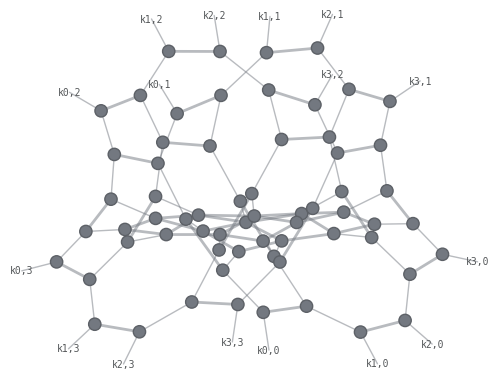

In [8]:
circuit_tnf.draw()

In [9]:
circuit_tnf

PEPS(tensors=64, indices=112, Lx=4, Ly=4, max_bond=4)

In [10]:
import quimb as qu
# extract the raw arrays and a skeleton of the TN
params, skeleton = qtn.pack(circuit_tnf)

# for torch, further flatten pytree into a single list
params_flat, params_pytree = qu.utils.tree_flatten(
    params, get_ref=True
)       

In [12]:
params_pytree

{0: Leaf,
 1: Leaf,
 2: Leaf,
 3: Leaf,
 4: Leaf,
 5: Leaf,
 6: Leaf,
 7: Leaf,
 8: Leaf,
 9: Leaf,
 10: Leaf,
 11: Leaf,
 12: Leaf,
 13: Leaf,
 14: Leaf,
 15: Leaf,
 16: Leaf,
 17: Leaf,
 18: Leaf,
 19: Leaf,
 20: Leaf,
 21: Leaf,
 22: Leaf,
 23: Leaf,
 24: Leaf,
 25: Leaf,
 26: Leaf,
 27: Leaf,
 28: Leaf,
 29: Leaf,
 30: Leaf,
 31: Leaf,
 32: Leaf,
 33: Leaf,
 34: Leaf,
 35: Leaf,
 36: Leaf,
 37: Leaf,
 38: Leaf,
 39: Leaf,
 40: Leaf,
 41: Leaf,
 42: Leaf,
 43: Leaf,
 44: Leaf,
 45: Leaf,
 46: Leaf,
 47: Leaf,
 48: Leaf,
 49: Leaf,
 50: Leaf,
 51: Leaf,
 52: Leaf,
 53: Leaf,
 54: Leaf,
 55: Leaf,
 56: Leaf,
 57: Leaf,
 58: Leaf,
 59: Leaf,
 60: Leaf,
 61: Leaf,
 62: Leaf,
 63: Leaf}

In [15]:
params_flat[16]

array([[[-1.00047662, -0.16013607,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.2264666 ]],

       [[ 0.        ,  0.        ,  0.2264666 ,  0.        ],
        [-1.00047662,  0.16013607,  0.        ,  0.        ]]])